#####          PROJET DE FIN DE FORMATION**DATAGONG-DATA ANALYST
 
       ETUDE ET ANALYSE DES DONNEES E-COMMERCE DE THELOOK-EUROPE

### Introduction:
Le travail demandé est de fournir en tant que Data Analyst une étude et une analyse comparative de la performance des activités e-commerce de TheLook Europe sur le périmètre métier: France-Département Women-années 2023_2024.
Il s'agit de comprendre les principales tendances des différentes activités et de mésurer leur évolution sur la base des KPIs suivants: chiffre d'affaires, marge brute, volume de commandes, panier moyen, retours et ré-achat des clients.
L'analyse vise également à identifier les tendances mensuelles, les contributions de différents paramètres/acteurs commerciaux et les éventuelles ruptures de performance dans le but d'éclairer les décisions du management.

La première étape de ce travail est consacrée à une **analyse exploratoire des données (EDA) réalisée en Python  sur la base du fichier CSV fourni**. Elle a deux objectifs : contrôler la qualité, la cohérence et la traçabilité des données, puis faire émerger des enseignements business permettant de comparer les performances de 2023 et 2024.

pour se faire, nous allons procéder successivement au chargement et à la compréhension du jeu de données, à la construction d'un mini dictionnaire de données, au contrôl de qualité, à l'analyse des distributions et contributions commerciales, à l'étude de la saisonnalité mensuelle, puis au calcul et à la comparaison des KPI annuels et mensuels.

Les indicateurs sont calculés selon les directives du cahier des charges. Le statut **`Complete`** est retenu comme convention de **vente réalisée** pour le chiffre d'affaires, la marge brute et le panier moyen. Le taux de retour est calculé sur la base des lignes **`Complete` + `Returned`**, tandis que le taux de ré-achat mesure la proportion de clients ayant effectué **au moins deux commandes complètes au cours d'une même année**.

Les résultats de cette partie serviront aux étapes suivantes : **validation des KPI par SQL dans BigQuery**, puis restitution dans un **tableau de bord Power BI**.


1.Cadrage du projet: Perimètre-Définition-Conventions

### Périmètre
- **Pays** : France
- **Département produit** : Women
- **Période d'étude** : 01/01/2023 au 31/12/2024
- **Source du notebook** : fichier CSV fourni pour l'EDA Python
- **Source de vérité du projet** : `bigquery-public-data.thelook_ecommerce`

### Convention concernant les statuts

| Statut | Interprétation analytique | Utilisation |
|---|---|---|
| `Complete` | Vente réalisée / commande complète | CA, marge, panier moyen, ré-achat |
| `Returned` | Article retourné | Taux de retour |
| `Shipped` | Article expédié | Analyse descriptive |
| `Processing` | Article en cours de traitement | Analyse descriptive |
| `Cancelled` | Article / commande annulé(e) | Analyse descriptive |

Les statuts `Shipped`, `Processing` et `Cancelled` ne sont pas considérés pour les ventes réalisées dans le traitement des KPIs. Les calculs du CA, de la marge brute et du panier moyen reposent exclusivement sur les lignes `Complete`.

### Définitions des KPIs

- **Chiffre d'affaires** : somme de `sale_price` sur les lignes `Complete`.
- **Marge brute** : somme de `sale_price - cost` sur les lignes `Complete`.
- **Panier moyen** : CA / nombre de commandes distinctes ayant généré un revenu positif.
- **Taux de retour** : lignes `Returned` / (`Complete` + `Returned`).
- **Taux de ré-achat** : clients ayant au moins 2 commandes `Complete` / clients ayant au moins 1 commande `Complete`, calculé par année.

### Convention temporelle

Pour l'analyse de performance commerciale, la date de référence retenue est **`delivered_at`**. Les contrôles de qualité portent néanmoins sur l'ensemble des dates afin d'identifier et documenter les incohérences sans supprimer arbitrairement les observations.

In [1]:
# Environnement de travail
from pathlib import Path # Manipuler les chemins vers dossiers et fichiers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append(str(Path("../src").resolve()))
from utils import top_contributors

sns.set_theme(style="whitegrid") # style graphique fond clair,grille visible
plt.rcParams["figure.figsize"] = (12, 6) # Définition de la taille par défaut des graphiques; largeur 12 hauteur 6
pd.set_option("display.max_columns", None) # Afficher toutes les colonnes disponibles
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")# séparateur de milier ","; et les nombres float auront 2 chiffres après la virgule

In [2]:
# Chargement du CSV;Le CSV se trouve dans ../data/thelook_fr_women_2023_2024.csv.
df = pd.read_csv("../data/thelook_fr_women_2023_2024.csv")

print(f"Nombre de lignes : {df.shape[0]:,}")
print(f"Nombre de colonnes : {df.shape[1]:,}")
display(df.head())

Nombre de lignes : 1,679
Nombre de colonnes : 20


,order_id,order_item_id,product_id,item_created_at,item_status,sale_price,cost,category,department,brand,product_name,order_status,order_created_at,shipped_at,delivered_at,user_id,gender,country,state,city
0,19425,28112,6983,2023-01-01 06:18:03+00:00,Shipped,29.50,16.05,Shorts,Women,Fox,Fox Juniors Momentum Short,Shipped,2022-12-29 10:00:00+00:00,2022-12-30 11:29:00+00:00,NaN,15644,F,France,Centre-Val de Loire,Corquilleroy
1,19425,28113,10597,2023-01-01 06:44:58+00:00,Shipped,20.00,10.00,Intimates,Women,Wacoal,Wacoal Women's B-Smooth Bralette,Shipped,2022-12-29 10:00:00+00:00,2022-12-30 11:29:00+00:00,NaN,15644,F,France,Centre-Val de Loire,Corquilleroy
2,4710,6730,11792,2023-01-03 04:44:50+00:00,Complete,38.00,18.47,Intimates,Women,American Apparel,American Apparel Striped Chiffon Tank,Complete,2023-01-03 08:12:00+00:00,2023-01-03 09:14:00+00:00,2023-01-04 03:03:00+00:00,3853,F,France,Île-de-France,Paris
3,16618,24006,329,2023-01-03 15:13:39+00:00,Complete,27.99,16.40,Tops & Tees,Women,Tri-Mountain,Tri-Mountain Women's 3/4-Sleeve Pique Knit Pol...,Complete,2023-01-03 18:58:00+00:00,2023-01-05 13:23:00+00:00,2023-01-09 10:25:00+00:00,13422,F,France,Hauts-de-France,Comines
4,4710,6731,5295,2023-01-05 06:43:09+00:00,Complete,56.88,29.58,Pants & Capris,Women,Lauren by Ralph Lauren,Lauren Ralph Lauren Velour Pants,Complete,2023-01-03 08:12:00+00:00,2023-01-03 09:14:00+00:00,2023-01-04 03:03:00+00:00,3853,F,France,Île-de-France,Paris


## 2. Compréhension du jeu de données

Chaque observation correspond à une **ligne d'article de commande (`order_item_id`)**; dans les aggrégations nous allons donc considérer que le nombre de lignes d'articles ne correspond pas nécessairement au nombre de commandes.

Cette section vérifie la structure du fichier, ses dimensions et les types de données avant toute transformation.

In [3]:
print(f"Taille du jeu de données:{df.shape}")
print(f"\nles types de données:")
display(df.dtypes.to_frame("dtype"))
print(f"\nInformations générales:\n")
df.info()

Taille du jeu de données:(1679, 20)

les types de données:


,dtype
order_id,int64
order_item_id,int64
product_id,int64
item_created_at,str
item_status,str
sale_price,float64
cost,float64
category,str
department,str
brand,str



Informations générales:

<class 'pandas.DataFrame'>
RangeIndex: 1679 entries, 0 to 1678
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          1679 non-null   int64  
 1   order_item_id     1679 non-null   int64  
 2   product_id        1679 non-null   int64  
 3   item_created_at   1679 non-null   str    
 4   item_status       1679 non-null   str    
 5   sale_price        1679 non-null   float64
 6   cost              1679 non-null   float64
 7   category          1679 non-null   str    
 8   department        1679 non-null   str    
 9   brand             1677 non-null   str    
 10  product_name      1679 non-null   str    
 11  order_status      1679 non-null   str    
 12  order_created_at  1679 non-null   str    
 13  shipped_at        1133 non-null   str    
 14  delivered_at      636 non-null    str    
 15  user_id           1679 non-null   int64  
 16  gender            1679 non-

In [4]:
# Mini dictionnaire de données construit à partir des colonnes réellement présentes.
definitions = {
    "order_id": "Identifiant unique de la commande.",
    "order_item_id": "Identifiant unique de la ligne d'article.",
    "product_id": "Identifiant du produit.",
    "item_created_at": "Date de création de la ligne d'article.",
    "item_status": "Statut de la ligne d'article.",
    "sale_price": "Prix de vente de l'article.",
    "cost": "Coût associé au produit.",
    "category": "Catégorie commerciale du produit.",
    "department": "Département commercial du produit.",
    "brand": "Marque du produit.",
    "product_name": "Nom du produit.",
    "order_status": "Statut global de la commande.",
    "order_created_at": "Date de création de la commande.",
    "shipped_at": "Date d'expédition.",
    "delivered_at": "Date de livraison.",
    "user_id": "Identifiant du client.",
    "gender": "Genre renseigné dans le profil client.",
    "country": "Pays du client.",
    "region": "Région du client, si disponible.",
    "state": "Subdivision géographique, si disponible.",
    "city": "Ville du client."
}
row:list[dict]=[]
for c in df.columns:
    row.append({
        "Colonnes":c,
        "Types":str(df[c].dtype),
        "Définitions":definitions.get(c,"Aucune Définition trouvée"),
        "Exemple":df[c].dropna().iloc[0] if df[c].notna().any else np.nan
    })
dictionnaire=pd.DataFrame(row)
display(dictionnaire)

,Colonnes,Types,Définitions,Exemple
0,order_id,int64,Identifiant unique de la commande.,19425
1,order_item_id,int64,Identifiant unique de la ligne d'article.,28112
2,product_id,int64,Identifiant du produit.,6983
3,item_created_at,str,Date de création de la ligne d'article.,2023-01-01 06:18:03+00:00
4,item_status,str,Statut de la ligne d'article.,Shipped
5,sale_price,float64,Prix de vente de l'article.,29.50
6,cost,float64,Coût associé au produit.,16.05
7,category,str,Catégorie commerciale du produit.,Shorts
8,department,str,Département commercial du produit.,Women
9,brand,str,Marque du produit.,Fox


## 3. Contrôle de qualité des données

Les contrôles couvrent quatre aspects : **valeurs manquantes, doublons, formats de dates et cohérence temporelle**.

Les anomalies seront documentées plutôt que supprimées; Cette approche protège la traçabilité entre le CSV fourni, les calculs Python, la source BigQuery et le futur modèle Power BI.

In [5]:
missing=df.isna().sum().to_frame("Nombre de valeurs manquantes")
missing["pourcentage"]=missing["Nombre de valeurs manquantes"]*100/len(df)
display(missing.sort_values("Nombre de valeurs manquantes",ascending=False))

,Nombre de valeurs manquantes,pourcentage
delivered_at,1043,62.12
shipped_at,546,32.52
brand,2,0.12
order_id,0,0.00
item_created_at,0,0.00
product_id,0,0.00
order_item_id,0,0.00
item_status,0,0.00
category,0,0.00
department,0,0.00


## 
La colonne **brand** est une variable catégorielle qui a 2 valeurs manquantes; nous ne pouvons pas les remplacer par une modalité car la modalité la plus fréquente a un taux de présence 6% (qui est <50%); calcul fait avec : df["brand"].value_counts(normalize=True)*100. Aussi, nous ne devons pas supprimer les lignes/colonnes correspondantes au risque de perdre des informations.

# 
La colonne **shipped_at** indique la date d'expédition. Une valeur manquante signifie souvent que la commande est: soit encore en cours de traitement **(Processing)** ou a été annulée **(Cancelled)** ; 
Regardons de plus près avec les statuts **(order_status)** correspondants à ces **valeurs manquantes**.

In [6]:
df[df["shipped_at"].isna()][["order_status","shipped_at"]]["order_status"].value_counts()

order_status
Processing    306
Cancelled     240
Name: count, dtype: int64

In [42]:
df["shipped_at"].isna().sum()

np.int64(546)

## 
Les 2 tableaux ci-dessus montrent que les valeurs manquantes de shipped_at sont principalement associées aux statuts Processing(306) et Cancelled(240); et on a 546=306+240. Cela confirme que les commandes avec des valeurs manquantes dans **shipped_at** sont **soit en cours de traitement, soit annulées**. Il est donc logique de conserver ces valeurs manquantes; car elles reflètent l'état réel des commandes. Pour les autres statuts, il n'y a pas de valeurs manquantes, ce qui indique que les commandes ont été expédiées ou livrées avec succès.

## 
La colonne **delivered_at** indique la date de livraison. Une valeur manquante signifie généralement que la commande n'a pas encore été livrée : elle est soit encore en cours de traitement **(Processing)**, soit en cours d'acheminement **(Shipped)**, soit elle a été annulée **(Cancelled)**
Regardons de plus près avec les statuts **(order_status)** correspondants à ces valeurs manquantes. 

In [43]:
df[df["delivered_at"].isna()][["order_status","delivered_at"]]["order_status"].value_counts()

order_status
Shipped       497
Processing    306
Cancelled     240
Name: count, dtype: int64

In [44]:
df["delivered_at"].isna().sum()

np.int64(1043)

## 
Les 2 tableaux ci-dessus montrent que les valeurs manquantes de delivered_at sont principalement associées aux statuts Processing(306),Shipped(497) et Cancelled(240); et on a 1043=306+497+240. Cela confirme que les commandes avec des valeurs manquantes dans delivered_at sont soit en cours de traitement **(Processing)**, soit en cours d'acheminement **(Shipped)**, soit  annulées **(Cancelled)**. Il est donc logique de conserver ces valeurs manquantes; car elles reflètent l'état réel des commandes. Pour les autres statuts, il n'y a pas de valeurs manquantes, ce qui indique que les commandes ont été expédiées ou livrées avec succès.

In [7]:
duplicated_nb=df.duplicated().sum()
print(f"Nombre de lignes entièrement dupliquées: {duplicated_nb}")
if duplicated_nb==0:
    print("aucun doublon détecté")
else:
    print(f"Des doublons sont présents et doivent être investigués")

Nombre de lignes entièrement dupliquées: 0
aucun doublon détecté


In [8]:
# Formats de Dates:
# Nous avons 4 variables date/heure : order_created_at, shipped_at, delivered_at et item_created_at. Nous allons vérifier si elles sont bien au format datetime.
df[["item_created_at","order_created_at","shipped_at","delivered_at"]].dtypes

item_created_at     str
order_created_at    str
shipped_at          str
delivered_at        str
dtype: object

In [9]:
# Le résultat montre que ces colonnes sont actuellement de type object (chaîne de caractères). Pour effectuer des analyses temporelles, il est nécessaire de les convertir en type datetime. Nous allons donc procéder à cette conversion.
colonnes_date = ["item_created_at","order_created_at","shipped_at","delivered_at"]
for i in colonnes_date:
  df[i]=pd.to_datetime(df[i])
  print(f"Le nouveau type de la colonne {i} est {df[i].dtype}")

Le nouveau type de la colonne item_created_at est datetime64[us, UTC]
Le nouveau type de la colonne order_created_at est datetime64[us, UTC]
Le nouveau type de la colonne shipped_at est datetime64[us, UTC]
Le nouveau type de la colonne delivered_at est datetime64[us, UTC]


In [10]:
for c in colonnes_date:
    print(f"\n--- {c} ---")
    print("Date minimale :", df[c].min())
    print("Date maximale :", df[c].max())
    print("Années observées :", sorted(df[c].dropna().dt.year.unique().tolist()))


--- item_created_at ---
Date minimale : 2023-01-01 06:18:03+00:00
Date maximale : 2024-12-31 10:40:48+00:00
Années observées : [2023, 2024]

--- order_created_at ---
Date minimale : 2022-12-29 10:00:00+00:00
Date maximale : 2024-12-31 05:13:00+00:00
Années observées : [2022, 2023, 2024]

--- shipped_at ---
Date minimale : 2022-12-30 11:29:00+00:00
Date maximale : 2025-01-02 02:26:00+00:00
Années observées : [2022, 2023, 2024, 2025]

--- delivered_at ---
Date minimale : 2023-01-04 03:03:00+00:00
Date maximale : 2025-01-02 13:06:00+00:00
Années observées : [2023, 2024, 2025]


In [11]:
# Tests de cohérence entre les différentes dates.
Test_coherence_dates: dict[str, int] = {}


Test_coherence_dates["Article créé après commande"] = (
        df["item_created_at"] > df["order_created_at"]
    ).sum()


Test_coherence_dates["Article créé après expédition"] = (
        (df["item_created_at"] > df["shipped_at"]) & df["shipped_at"].notna()
    ).sum()


Test_coherence_dates["Article créé après livraison"] = (
        (df["item_created_at"] > df["delivered_at"]) & df["delivered_at"].notna()
    ).sum()


Test_coherence_dates["Livraison avant expédition"] = (
        (df["shipped_at"] > df["delivered_at"])
        & df["shipped_at"].notna()
        & df["delivered_at"].notna()
    ).sum()

display(pd.Series(Test_coherence_dates, name="Nombre de lignes concernées").to_frame())

,Nombre de lignes concernées
Article créé après commande,775
Article créé après expédition,375
Article créé après livraison,63
Livraison avant expédition,0


###  Interprétation des contrôles temporels

Le tableau montre que des incohérences temporelles sont présentes dans le dataset fourni, notamment lorsque `item_created_at` est postérieure à une date de commande('order_created_at'), d'expédition('shipped_at') ou de livraison('delivered_at'). Ces anomalies doivent être conservées et documentées.

**Remarque** : « La date de création de l'article peut être postérieure à celle de la commande si le modèle autorise l'ajout d'un article après la création initiale de la commande. Cette situation ne doit donc pas être automatiquement considérée comme une incohérence ; elle doit être interprétée en fonction de la définition métier de item_created_at. »

Pour les KPI de performance commerciale, une règle homogène est appliquée : les ventes retenues sont les lignes **`item_status = Complete`** dont **`delivered_at` appartient à 2023 ou 2024**. Cette convention permet de comparer les deux années sur une base stable.


## 4. Analyse des statuts

Avant les KPI, il est utile de comprendre la composition du périmètre. Cette analyse est descriptive et sert également à vérifier que les conventions métier du projet correspondent aux valeurs réellement observées.

In [12]:
statuts=df["item_status"].value_counts(dropna=False).rename("nombre").to_frame()
statuts["pourcentage"]=round(df["item_status"].value_counts(normalize=True,dropna=False)*100,2)
display(statuts)

,nombre,pourcentage
item_status,,
Shipped,497,29.60
Complete,425,25.31
Processing,306,18.23
Cancelled,240,14.29
Returned,211,12.57


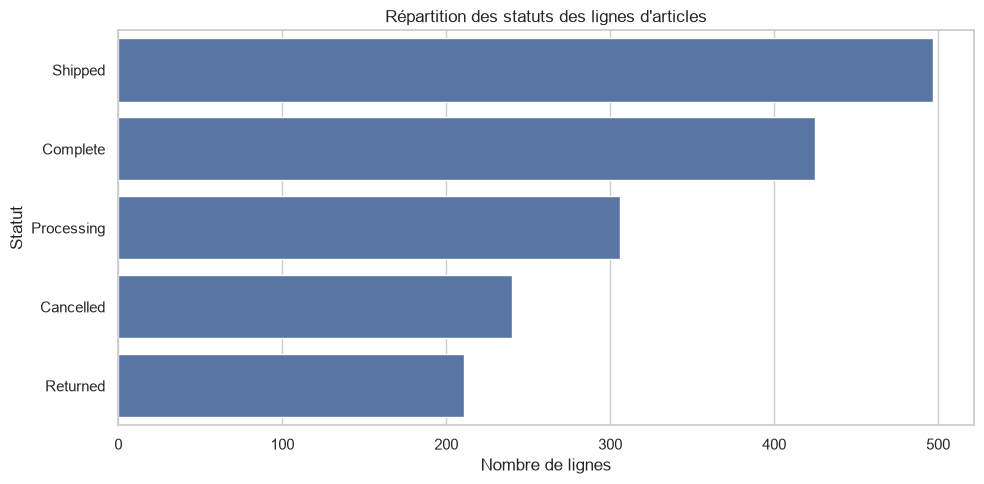

In [13]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    y="item_status",
    order=df["item_status"].value_counts().index
)
plt.title("Répartition des statuts des lignes d'articles")
plt.xlabel("Nombre de lignes")
plt.ylabel("Statut")
plt.tight_layout()#Ajuster automatiquement l'espacement entre les éléments graphiques pour qu'ils ne se chevauchent pas.
plt.show()

La répartition précédente des statuts des articles montre que 29,6 % des articles sont expédiés (Shipped), ce qui en fait le statut le plus représenté. Les articles complétés (Complete) représentent 25,3 % des observations, indiquant qu'environ un quart des articles ont été livrés et finalisés. Par ailleurs, 18,2 % des articles sont encore en cours de traitement (Processing). 
Enfin, les statuts Cancelled (14,3 %) et Returned (12,6 %) représentent ensemble près de 27 % des articles, ce qui traduit une proportion non négligeable d'articles n'ayant pas abouti à une vente définitive.
Il serait donc important de nous pencher sur les catégories, marques et villes qui ont les plus grands taux d'annulation et de retour de commande.


In [14]:
# Categories, taux d'annulation
pd.crosstab(
    df["category"],
    df["item_status"],
    normalize="index"
).mul(100).round(2).sort_values(by="Cancelled",ascending=False).head(15)

item_status,Cancelled,Complete,Processing,Returned,Shipped
category,,,,,
Leggings,24.53,32.08,15.09,15.09,13.21
Suits,22.22,11.11,16.67,16.67,33.33
Jeans,21.59,20.45,19.32,7.95,30.68
Outerwear & Coats,20.00,23.33,13.33,18.33,25.00
Swim,18.89,24.44,8.89,11.11,36.67
Active,17.46,22.22,15.87,12.70,31.75
Tops & Tees,17.00,20.00,11.00,18.00,34.00
Maternity,15.46,23.71,19.59,13.40,27.84
Plus,14.81,23.46,20.99,13.58,27.16


D'après le résultat d'en haut, le taux d'annulation au niveau des catégories de produit n'est pas très parlant; car nous avons un taux d'annulation max de 24.53 %. Je trouve que ça n'interpelle pas assez.

In [15]:
# Categories, taux de retour

pd.crosstab(
    df["category"],
    df["item_status"],
    normalize="index"
).mul(100).round(2).sort_values(by="Returned",ascending=False).head(15)

item_status,Cancelled,Complete,Processing,Returned,Shipped
category,,,,,
Clothing Sets,0.00,0.00,50.00,50.00,0.00
Blazers & Jackets,11.76,17.65,25.49,21.57,23.53
Outerwear & Coats,20.00,23.33,13.33,18.33,25.00
Tops & Tees,17.00,20.00,11.00,18.00,34.00
Suits,22.22,11.11,16.67,16.67,33.33
Socks & Hosiery,11.29,27.42,12.90,16.13,32.26
Leggings,24.53,32.08,15.09,15.09,13.21
Skirts,9.76,24.39,19.51,14.63,31.71
Shorts,11.39,21.52,12.66,13.92,40.51


Je crois que ici, nous avons la catégorie "Clothing Sets" qui doit interpeller; car elle a un taux de retour de produit de 50 %.
Et les taux de shipped et complete tous à 0 % augmentent la probabilité de voir les 50 % en processing être aussi retournés par la suite. La categorie "Clothing Sets" doit interpeller les équipes metiers.

In [16]:
# marques, taux d'annulation

pd.crosstab(
    df["brand"],
    df["item_status"],
    normalize="index"
).mul(100).round(2).sort_values(by="Cancelled",ascending=False).head(98)

item_status,Cancelled,Complete,Processing,Returned,Shipped
brand,,,,,
Vitamin A,100.00,0.00,0.00,0.00,0.00
Vivian's Fashions,100.00,0.00,0.00,0.00,0.00
Alan Sloane,100.00,0.00,0.00,0.00,0.00
Terramar,100.00,0.00,0.00,0.00,0.00
Tea Collection,100.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...
Disney,50.00,0.00,50.00,0.00,0.00
DG Eyewear,50.00,50.00,0.00,0.00,0.00
CoreyLynnCalter,50.00,0.00,50.00,0.00,0.00


Nous avons 58 marques qui ont taux d'annulation à 100 %; et 97 marques qui ont un taux d'annulation supérieur ou égal à 50 %. Ces marquent doivent interpeller les équipes metiers.

In [17]:
# marques, taux de retour

pd.crosstab(
    df["brand"],
    df["item_status"],
    normalize="index"
).mul(100).round(2).sort_values(by="Returned",ascending=False).head(80)

item_status,Cancelled,Complete,Processing,Returned,Shipped
brand,,,,,
Pettipant,0.00,0.00,0.00,100.00,0.00
David Kahn,0.00,0.00,0.00,100.00,0.00
Weber's Leather,0.00,0.00,0.00,100.00,0.00
Jeanstar,0.00,0.00,0.00,100.00,0.00
Miss Elaine,0.00,0.00,0.00,100.00,0.00
...,...,...,...,...,...
Merrell,0.00,50.00,0.00,50.00,0.00
Jolt,0.00,0.00,0.00,50.00,50.00
Sweatsedo,0.00,0.00,0.00,50.00,50.00


45 marques ont un taux de retour à 100 % ; et 79 marques ayant un taux de retour supérieur ou égal à 50 %. Ces marques doivent interpeller les équipes metier.

In [18]:
# Ville, taux d'annulation
pd.crosstab(
    df["city"],
    df["item_status"],
    normalize="index"
).mul(100).round(2).sort_values(by="Cancelled",ascending=False).head(78)

item_status,Cancelled,Complete,Processing,Returned,Shipped
city,,,,,
La Neuville-Chant-d'Oisel,100.00,0.00,0.00,0.00,0.00
Mozé-sur-Louet,100.00,0.00,0.00,0.00,0.00
Agnetz,100.00,0.00,0.00,0.00,0.00
Oyonnax,100.00,0.00,0.00,0.00,0.00
Saint-Pierre-lès-Elbeuf,100.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...
Arras,50.00,0.00,0.00,50.00,0.00
Châtenay-Malabry,50.00,0.00,0.00,50.00,0.00
Violaines,50.00,0.00,0.00,50.00,0.00


Nous avons 44 villes avec un taux d'annulation de 100 % ; et 77 villes avec un taux d'annulation supérieur ou égal à 50 %. Ceci doit interpeller les équipes business.

In [19]:
# Ville, taux de retour
pd.crosstab(
    df["city"],
    df["item_status"],
    normalize="index"
).mul(100).round(2).sort_values(by="Returned",ascending=False).head(71)

item_status,Cancelled,Complete,Processing,Returned,Shipped
city,,,,,
Aix-Noulette,0.00,0.00,0.00,100.00,0.00
Épieds-en-Beauce,0.00,0.00,0.00,100.00,0.00
Éragny,0.00,0.00,0.00,100.00,0.00
Athis-Val-de-Rouvre,0.00,0.00,0.00,100.00,0.00
Talmont-Saint-Hilaire,0.00,0.00,0.00,100.00,0.00
...,...,...,...,...,...
Orange,0.00,0.00,0.00,50.00,50.00
Brive-la-Gaillarde,0.00,0.00,0.00,50.00,50.00
Gourgé,0.00,0.00,0.00,50.00,50.00


Nous avons 36 villes avec un taux de retour de 100 % ; et 70 villes avec un taux de retour supérieur ou égal à 50 %. Ces villes doivent attirer l'attention des équipes metiers.

## 5. Distributions du prix de vente et du coût

Les distributions de `sale_price` et `cost` sont étudiées sur les lignes `Complete`, car ce sont les observations retenues pour les KPI financiers.

L'objectif est d'identifier la dispersion, l'asymétrie et les valeurs extrêmes pouvant influencer la moyenne et le panier moyen.

In [20]:
sales_mask = (
    (df["item_status"] == "Complete")
    & df["delivered_at"].notna()
    & df["delivered_at"].dt.year.isin([2023, 2024])
)

sales = df.loc[sales_mask].copy()
sales["year"] = sales["delivered_at"].dt.year
sales["month"] = sales["delivered_at"].dt.month
sales["gross_margin"] = sales["sale_price"] - sales["cost"]

print(f"Lignes Complete retenues : {len(sales):,}")

Lignes Complete retenues : 423


In [21]:
display(sales["sale_price"].describe().to_frame("sale_price"))
display(sales["cost"].describe().to_frame("cost"))

,sale_price
count,423.00
mean,55.43
std,71.57
min,1.82
25%,18.61
50%,36.29
75%,62.50
max,903.00


,cost
count,423.00
mean,26.66
std,33.77
min,0.75
25%,8.73
50%,17.97
75%,29.69
max,437.05


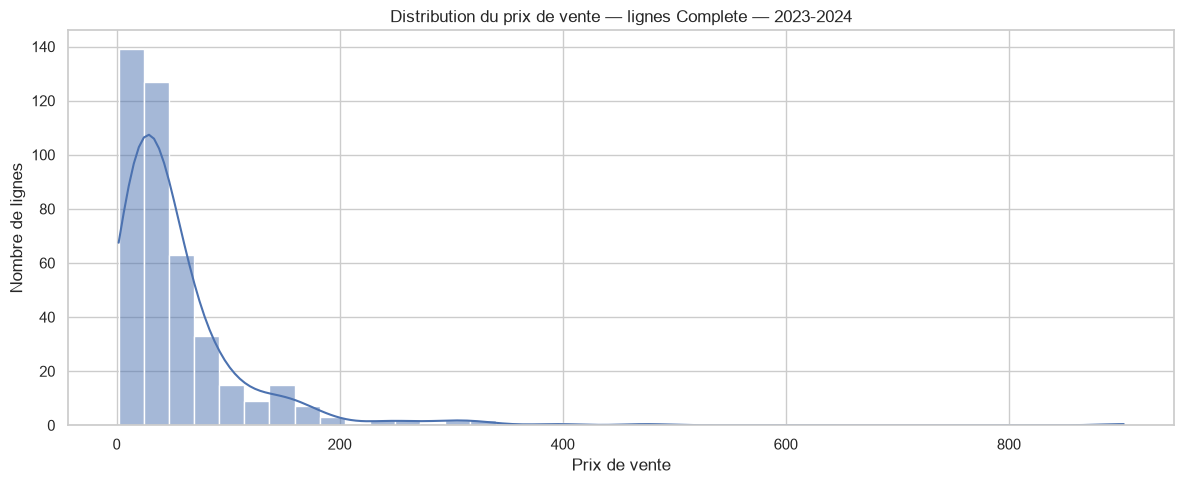

In [22]:
plt.figure(figsize=(12, 5))
sns.histplot(sales["sale_price"], bins=40, kde=True)
plt.title("Distribution du prix de vente — lignes Complete — 2023-2024")
plt.xlabel("Prix de vente")
plt.ylabel("Nombre de lignes")
plt.tight_layout()
plt.show()

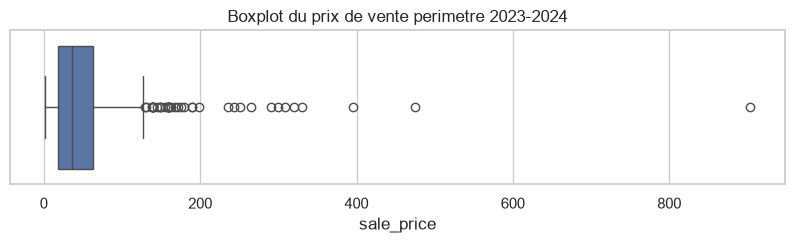

In [23]:
plt.figure(figsize=(10,2))

sns.boxplot(
    data=sales,
    x="sale_price"
)

plt.title("Boxplot du prix de vente perimetre 2023-2024")
plt.show()

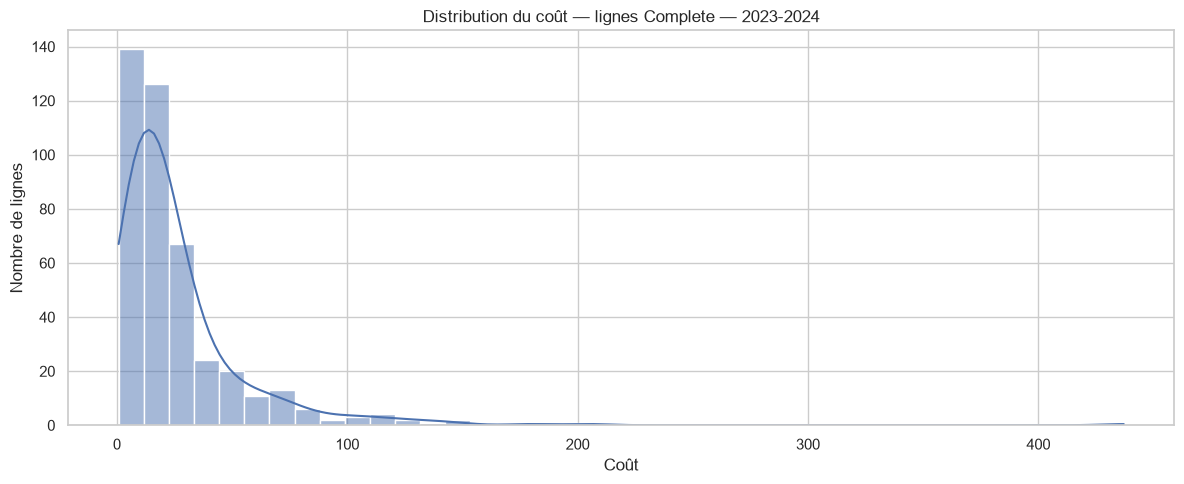

In [24]:
plt.figure(figsize=(12, 5))
sns.histplot(sales["cost"], bins=40, kde=True)
plt.title("Distribution du coût — lignes Complete — 2023-2024")
plt.xlabel("Coût")
plt.ylabel("Nombre de lignes")
plt.tight_layout()
plt.show()

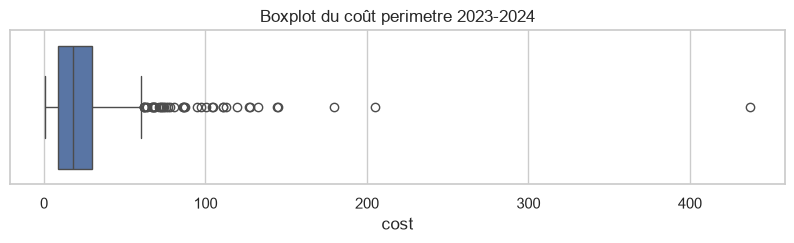

In [25]:
plt.figure(figsize=(10,2))

sns.boxplot(
    data=sales,
    x="cost"
)

plt.title("Boxplot du coût perimetre 2023-2024")
plt.show()

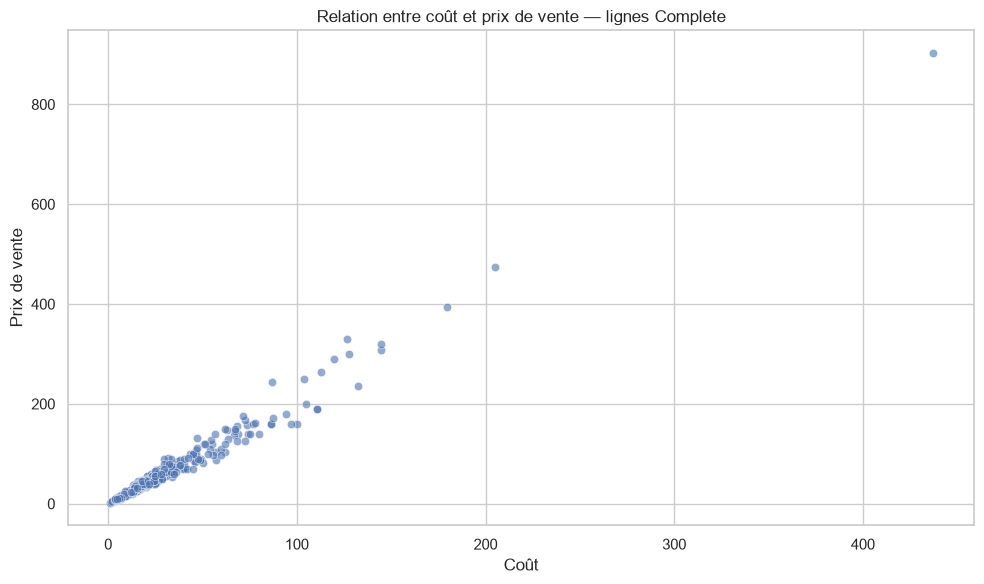

In [26]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=sales, x="cost", y="sale_price", alpha=0.6)
plt.title("Relation entre coût et prix de vente — lignes Complete")
plt.xlabel("Coût")
plt.ylabel("Prix de vente")
plt.tight_layout()
plt.show()

### Lecture analytique
Nous constatons que La variable prix de vente présente une forte dispersion (écart-type = 71,57), supérieure à sa moyenne (55,43), ce qui traduit une grande variabilité des montants de vente. La moyenne étant nettement supérieure à la médiane (36,29), la distribution semble asymétrique à droite, probablement sous l'effet de quelques ventes très élevées. En effet, 75 % des ventes sont inférieures à 62,50 alors que le maximum atteint 903, ce qui suggère la présence de valeurs aberrantes; valeurs aberrantes confirmées par le boxplot. Même analyse(constat) pour la variable "cost".

Une distribution fortement asymétrique signifie que quelques articles à prix élevé peuvent influencer fortement la moyenne. Il est donc pertinent de ne pas se limiter à la moyenne (car influencée) mais aussi regarder médiane et les quartiles par exemple, pour mieux interpreter les données.

Cette analyse prépare l'interprétation du panier moyen : une variation du CA peut provenir du **volume de commandes**, du **panier moyen** ou d'un changement du **mix produit**.

## 6. Contributions au chiffre d'affaires

Les contributions des **marques, catégories et villes** sont étudiées sur les lignes `Complete`.

Le Top 15 est utilisé pour conserver une lecture lisible tout en identifiant les principaux contributeurs au chiffre d'affaires.

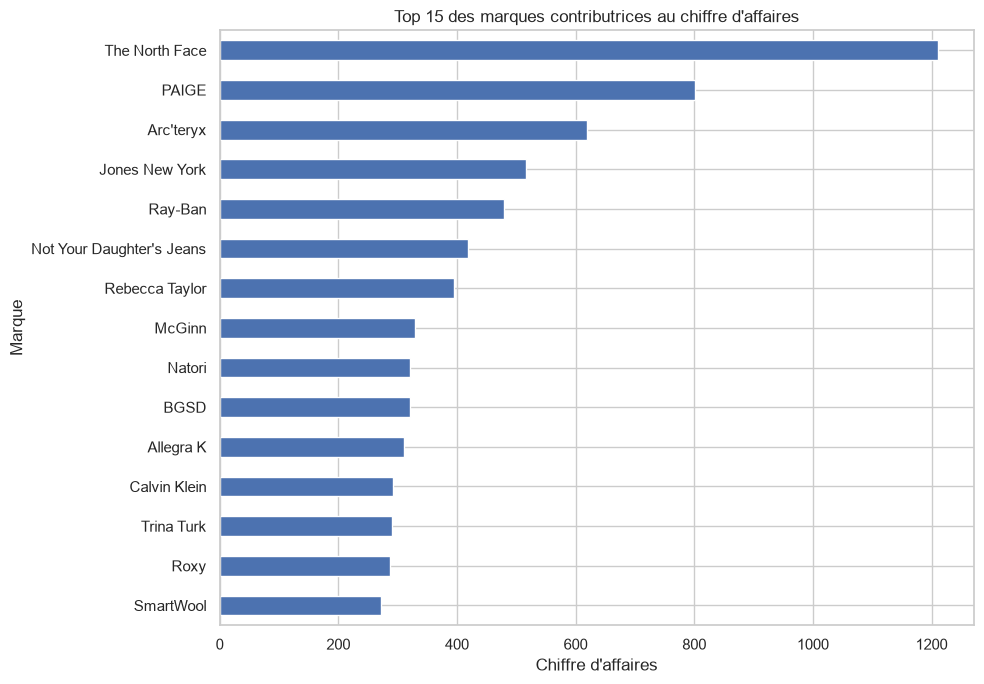

In [27]:
# J'appelle la fonction top_contributor définie dans le dossier src-->utils.py
top_brands = top_contributors(sales, "brand")
plt.figure(figsize=(10, 7))
top_brands.plot(kind="barh")
plt.title("Top 15 des marques contributrices au chiffre d'affaires")
plt.xlabel("Chiffre d'affaires")
plt.ylabel("Marque")
plt.tight_layout()
plt.show()

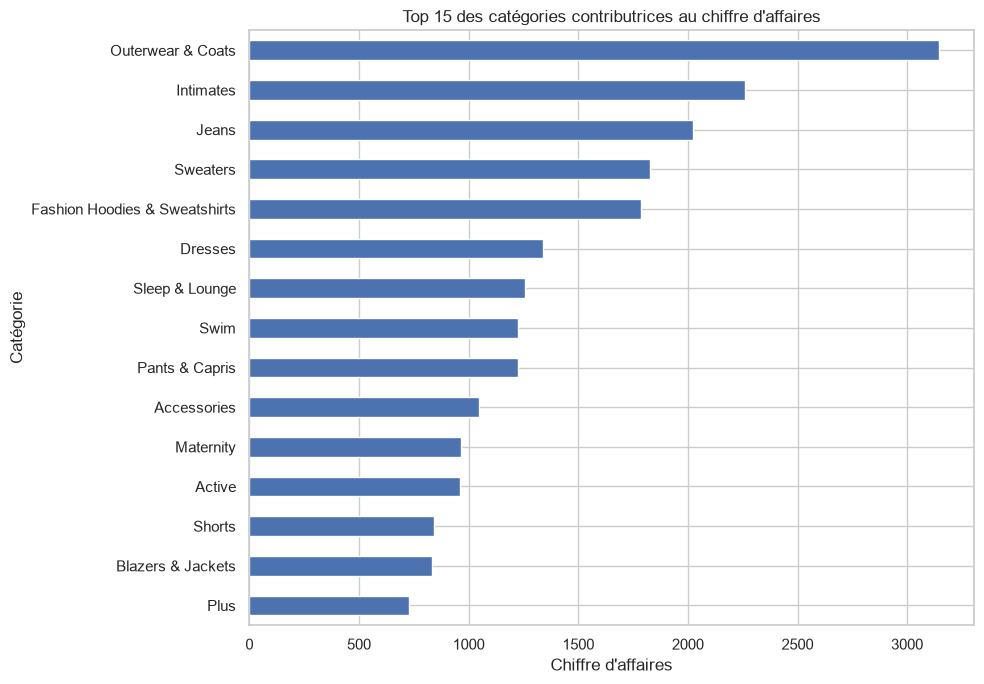

In [28]:
# J'appelle la fonction top_contributor définie dans le dossier src-->utils.py
top_categories = top_contributors(sales, "category")
plt.figure(figsize=(10, 7))
top_categories.plot(kind="barh")
plt.title("Top 15 des catégories contributrices au chiffre d'affaires")
plt.xlabel("Chiffre d'affaires")
plt.ylabel("Catégorie")
plt.tight_layout()
plt.show()

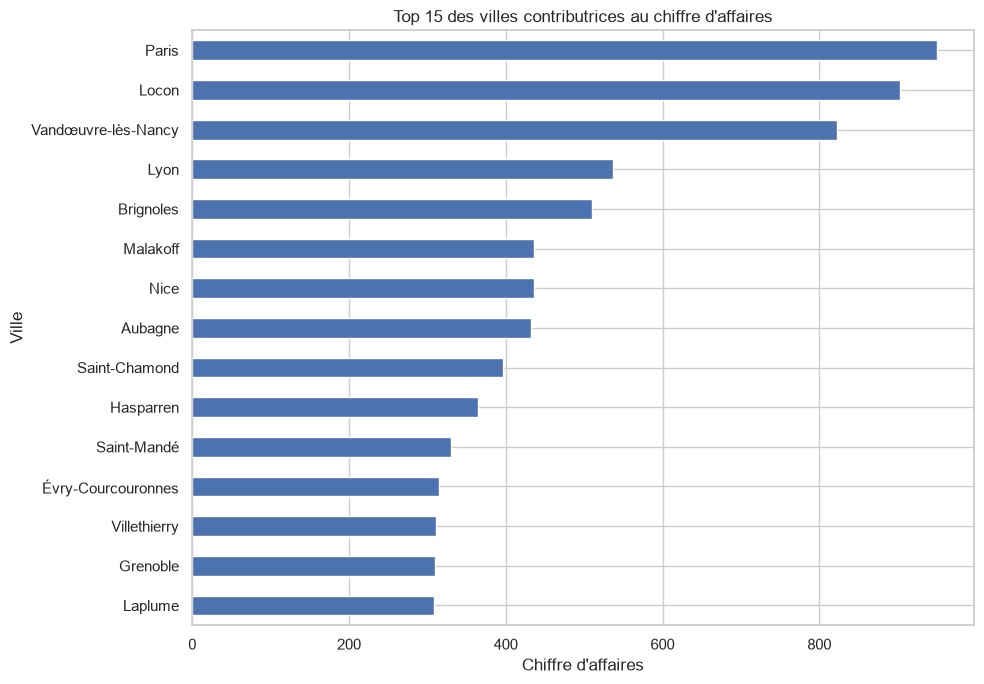

In [29]:
# J'appelle la fonction top_contributor définie dans le dossier src-->utils.py
top_cities = top_contributors(sales, "city")
plt.figure(figsize=(10, 7))
top_cities.plot(kind="barh")
plt.title("Top 15 des villes contributrices au chiffre d'affaires")
plt.xlabel("Chiffre d'affaires")
plt.ylabel("Ville")
plt.tight_layout()
plt.show()

## 7. Saisonnalité mensuelle

La date `delivered_at` est utilisée comme date de référence pour rattacher les ventes complètes à 2023 ou 2024.

Les séries mensuelles permettent d'identifier les mois de forte activité, les creux et les ruptures de tendance entre les deux années.

In [30]:
monthly = (
    sales.groupby(["year", "month"], as_index=False)
         .agg(
             chiffre_affaires=("sale_price", "sum"),
             marge_brute=("gross_margin", "sum"),
             commandes=("order_id", "nunique"),
             lignes=("order_item_id", "nunique")
         )
)

monthly["panier_moyen"] = monthly["chiffre_affaires"] / monthly["commandes"]
display(monthly)

,year,month,chiffre_affaires,marge_brute,commandes,lignes,panier_moyen
0,2023,1,375.56,188.28,7,11,53.65
1,2023,2,259.63,131.51,6,9,43.27
2,2023,3,299.12,149.21,7,9,42.73
3,2023,4,423.34,240.82,6,9,70.56
4,2023,5,938.77,485.36,10,17,93.88
5,2023,6,470.20,238.78,8,15,58.77
6,2023,7,214.97,118.68,5,8,42.99
7,2023,8,663.16,334.21,7,11,94.74
8,2023,9,"1,486.06",765.05,8,8,185.76
9,2023,10,"1,049.90",554.27,7,10,149.99


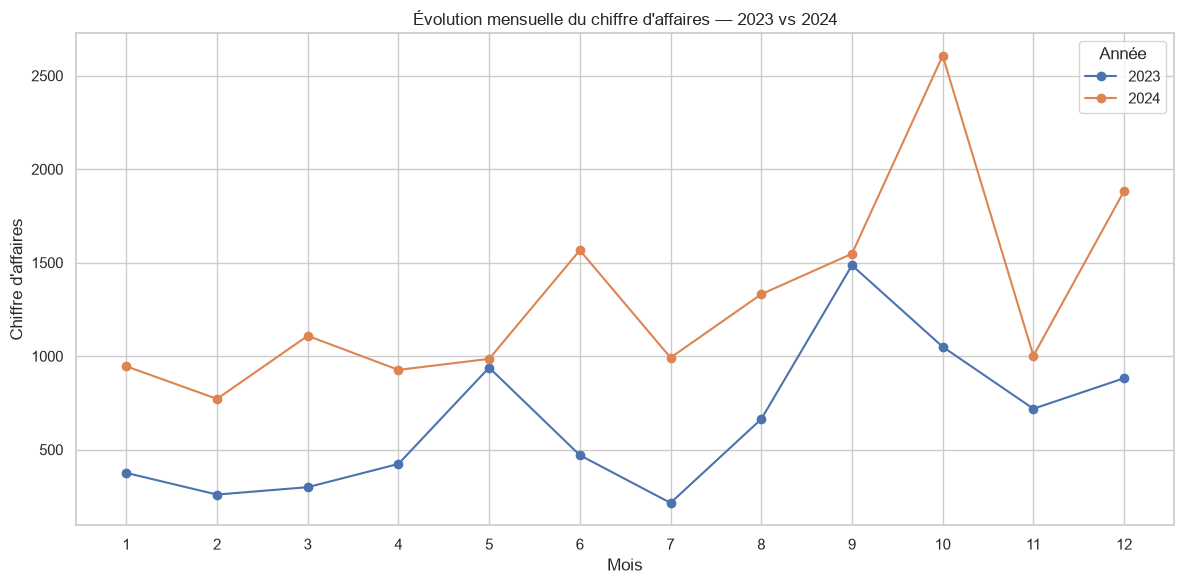

In [31]:
pivot_chiffre_affaire = monthly.pivot(index="month", columns="year", values="chiffre_affaires")

plt.figure(figsize=(12, 6))
for year in pivot_chiffre_affaire.columns:
    plt.plot(pivot_chiffre_affaire.index, pivot_chiffre_affaire[year], marker="o", label=str(year))

plt.title("Évolution mensuelle du chiffre d'affaires — 2023 vs 2024")
plt.xlabel("Mois")
plt.ylabel("Chiffre d'affaires")
plt.xticks(range(1, 13))
plt.legend(title="Année")
plt.tight_layout()
plt.show()

*******Analyse par mois*******
-Janvier à avril : le chiffre d'affaires de 2024 est largement supérieur à celui de 2023. Le début de l'année est donc nettement meilleur.
-Mai : les deux années sont très proches. C'est le mois où la progression est la plus faible.
-Juin : forte reprise en 2024 avec un chiffre d'affaires dépassant largement celui de 2023.
-Juillet à août : la progression reste importante, ce qui indique que l'activité estivale a été beaucoup plus dynamique en 2024.
-Septembre : les deux années sont relativement proches, même si 2024 reste légèrement supérieure.
-Octobre : c'est le mois qui présente la plus forte différence. Le chiffre d'affaires passe d'environ 1 050 en 2023 à près de 2 600 en 2024, soit une hausse d'environ 150 %.
-Novembre et décembre : la fin de l'année 2024 reste très performante, notamment en décembre où le chiffre d'affaires est environ deux fois supérieur à celui de 2023.

*******Saisonnalité*******
On observe également une évolution différente selon les années :
-En 2023, le chiffre d'affaires atteint son maximum en septembre, puis diminue en octobre et novembre, pour clôturer l'année avec un léger rebond en décembre..
-En 2024, la croissance se poursuit jusqu'en octobre, qui constitue le meilleur mois de l'année, avant une légère baisse en novembre puis un rebond en décembre.

Cette différence entre 2023 et 2024 peut traduire :

-une meilleure stratégie commerciale;
-des campagnes promotionnelles plus efficaces;
-un volume de commandes plus élevé;
-ou encore une augmentation du panier moyen.

Le tableau comparatif en haut confirme un volume plus élevé et aussi une augmentation du panier moyen en 2024, comparé à 2023.

Remarque : La baisse du chiffre d'affaires observée au mois de novembre, aussi bien en 2023 qu'en 2024, peut être dûe soit à la chute du nombre de ventes, soit la baisse du prix moyen par article. Le tableau en haut ne nous permet pas de conclure concernant le nombre de ventes. Regardons dans la cellule suivante le prix moyen par article . 

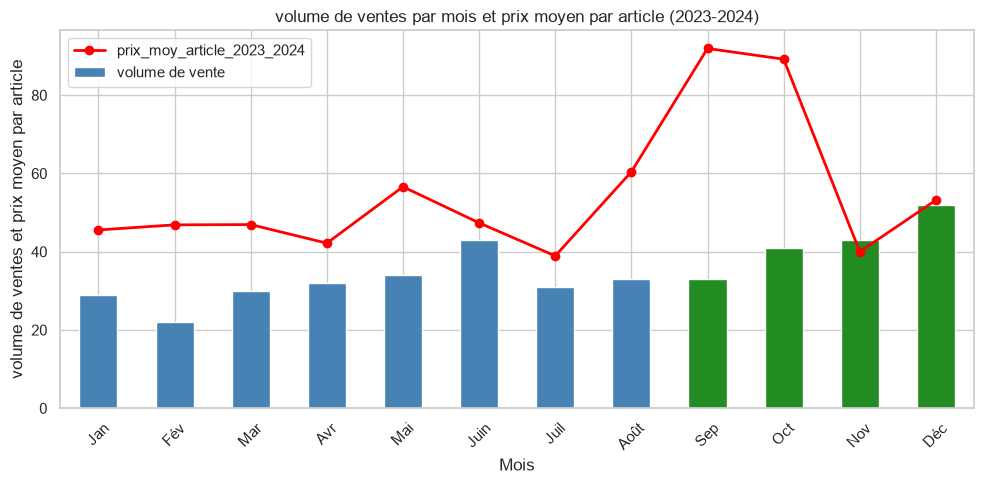

In [32]:
# Regardons mensuellement les volumes de ventes et les prix moyens des articles; prêtons attention aux mois octobre-novembre.

# prix moyen article
x=np.arange(0,12)
months=np.arange(1,13)
prix_moy_article: list[float]=[]
for i in months:
    prix_moy_article.append(sales[sales["delivered_at"].dt.month==i]["sale_price"].mean().round(2))
prix_moy_article_2023_2024=pd.Series(prix_moy_article)



# Volume de ventes
volumes_ventes_par_mois_2023_2024 = sales.groupby(
    sales["delivered_at"].dt.month
).size()

# Couleurs des barres
couleurs = ["steelblue"] * 8 + ["forestgreen"] * 4

fig,axi=plt.subplots(figsize=(10, 5))

volumes_ventes_par_mois_2023_2024.plot(
    kind="bar",
    color=couleurs,
    label="volume de vente",
    ax=axi
)

axi.plot(
    x,
    prix_moy_article_2023_2024.values,
    color="red",
    marker="o",
    linewidth=2,
    label="prix_moy_article_2023_2024"
)

plt.title("volume de ventes par mois et prix moyen par article (2023-2024)")
plt.xlabel("Mois")
plt.ylabel("volume de ventes et prix moyen par article")
axi.legend()
plt.xticks(
    ticks=range(12),
    labels=[
        "Jan", "Fév", "Mar", "Avr", "Mai", "Juin",
        "Juil", "Août", "Sep", "Oct", "Nov", "Déc"
    ],
    rotation=45
)

plt.tight_layout()

Ce schéma nous montre que la baisse du chiffre d'affaires observée au mois de novembre, aussi bien en 2023 qu'en 2024 s'explique principalement par une baisse du prix moyen des articles vendus au cours de ce mois.

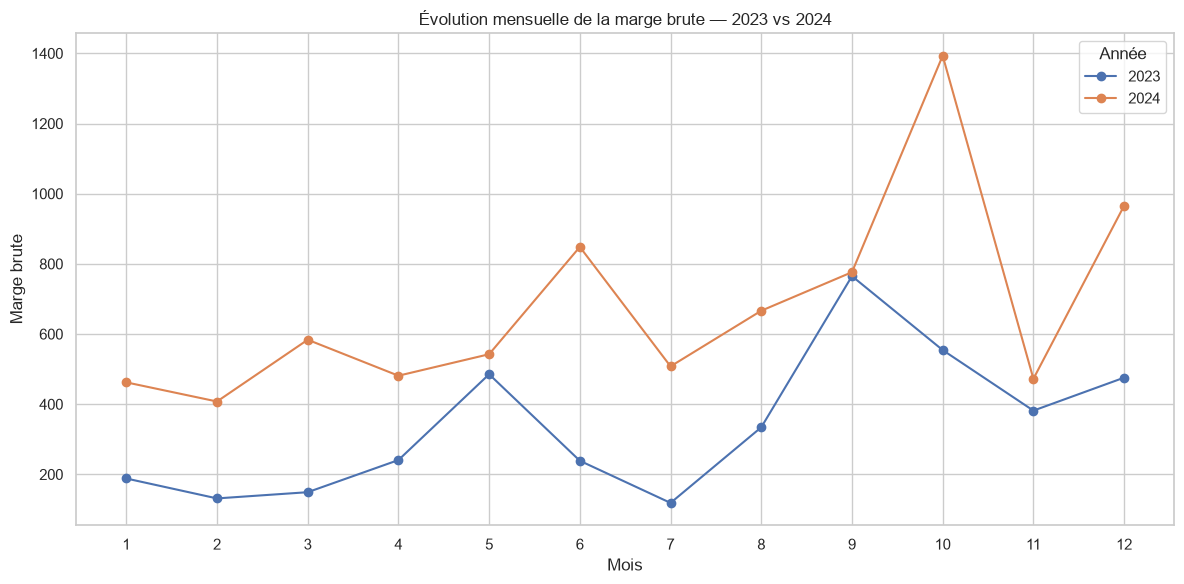

In [33]:
# Evolution mensuelle de la marge brute
pivot_margin = monthly.pivot(index="month", columns="year", values="marge_brute")

plt.figure(figsize=(12, 6))
for year in pivot_margin.columns:
    plt.plot(pivot_margin.index, pivot_margin[year], marker="o", label=str(year))

plt.title("Évolution mensuelle de la marge brute — 2023 vs 2024")
plt.xlabel("Mois")
plt.ylabel("Marge brute")
plt.xticks(range(1, 13))
plt.legend(title="Année")
plt.tight_layout()
plt.show()


## 8. Calcul des KPI annuels

Les KPI sont calculés séparément puis réunis dans un tableau de synthèse.

La logique respecte strictement les définitions du cahier des charges :
- CA et marge : lignes `Complete` ;
- panier moyen : CA / commandes distinctes à revenu positif ;
- taux de retour : `Returned / (Complete + Returned)` ;
- ré-achat : clients avec au moins deux commandes `Complete` sur une année.

In [34]:

# CA, marge brute, nombre de commandes et panier moyen
kpis = []

for year, grp in sales.groupby("year"):
    ca = grp["sale_price"].sum()
    margin = grp["gross_margin"].sum()
    n_orders = grp.loc[grp["sale_price"] > 0, "order_id"].nunique()
    aov = ca / n_orders if n_orders else np.nan

    kpis.append({
        "Année": year,
        "Chiffre d'affaires": ca,
        "Marge brute": margin,
        "Nombre de commandes": n_orders,
        "Panier moyen": aov
    })
kpis = pd.DataFrame(kpis).sort_values("Année")
display(kpis)

,Année,Chiffre d'affaires,Marge brute,Nombre de commandes,Panier moyen
0,2023,"7,781.33","4,063.52",96,81.06
1,2024,"15,667.27","8,107.51",183,85.61


In [35]:
# Taux de retour = Returned / (Complete + Returned)
return_s = df[
    df["item_status"].isin(["Complete", "Returned"])
    & df["delivered_at"].notna()
    & df["delivered_at"].dt.year.isin([2023, 2024])
].copy()

return_s["year"] = return_s["delivered_at"].dt.year

return_table = (
    return_s.groupby("year")["order_item_id"]
    .nunique()
    .rename("Complete + Returned")
    .to_frame()
)

returned = (
    return_s[return_s["item_status"] == "Returned"]
    .groupby("year")["order_item_id"]
    .nunique()
    .rename("Returned")
)

return_table = return_table.join(returned, how="left").fillna(0)
return_table["Taux de retour (%)"] = (
    return_table["Returned"] / return_table["Complete + Returned"] * 100
)

display(return_table.reset_index().rename(columns={"year": "Année"}))


,Année,Complete + Returned,Returned,Taux de retour (%)
0,2023,234,89,38.03
1,2024,400,122,30.50


In [36]:
# Taux de ré-achat par année.
# Dénominateur : clients ayant au moins une commande Complete.
# Numérateur : clients ayant au moins deux commandes Complete.

orders_per_customer = (
    sales.groupby(["year", "user_id"])["order_id"]
    .nunique()
    .reset_index(name="nombre_commandes")
)

repurchase = (
    orders_per_customer.groupby("year")
    .agg(
        clients_1_commande_ou_plus=("user_id", "nunique"),
        clients_2_commandes_ou_plus=("nombre_commandes", lambda x: (x >= 2).sum())
    )
)

repurchase["Taux de ré-achat (%)"] = (
    repurchase["clients_2_commandes_ou_plus"]
    / repurchase["clients_1_commande_ou_plus"] * 100
)

display(repurchase.reset_index().rename(columns={"year": "Année"}))

,Année,clients_1_commande_ou_plus,clients_2_commandes_ou_plus,Taux de ré-achat (%)
0,2023,96,0,0.00
1,2024,176,6,3.41


In [37]:
# Tableau final des KPI.
kpi = kpis.set_index("Année").copy()
kpi["Taux de retour (%)"] = return_table["Taux de retour (%)"]
kpi["Taux de ré-achat (%)"] = repurchase["Taux de ré-achat (%)"]
kpi = kpi.reset_index()

display(kpi.round(2))

,Année,Chiffre d'affaires,Marge brute,Nombre de commandes,Panier moyen,Taux de retour (%),Taux de ré-achat (%)
0,2023,"7,781.33","4,063.52",96,81.06,38.03,0.00
1,2024,"15,667.27","8,107.51",183,85.61,30.50,3.41


In [38]:
# Comparaison 2023 - 2024 : écarts absolus et relatifs.
compar = kpi.set_index("Année").T
compar = compar.rename(columns={2023: "2023", 2024: "2024"})

compar["Écart absolu"] = compar["2024"] - compar["2023"]
compar["Variation relative (%)"] = np.where(
    compar["2023"] != 0,
    compar["Écart absolu"] / compar["2023"] * 100,
    np.nan
)

display(compar.round(2))

Année,2023,2024,Écart absolu,Variation relative (%)
Chiffre d'affaires,"7,781.33","15,667.27","7,885.94",101.34
Marge brute,"4,063.52","8,107.51","4,043.98",99.52
Nombre de commandes,96.00,183.00,87.00,90.62
Panier moyen,81.06,85.61,4.56,5.62
Taux de retour (%),38.03,30.50,-7.53,-19.81
Taux de ré-achat (%),0.00,3.41,3.41,NaN


## 9. Comparaison mensuelle et identification des ruptures

Une progression annuelle peut masquer des évolutions très différentes selon les mois. L'analyse mensuelle permet donc de distinguer une croissance régulière d'une croissance concentrée sur quelques périodes.

Les facteurs à rapprocher sont le CA, le nombre de commandes, le panier moyen et la marge brute. Cette lecture permet de déterminer d'où vient la performance

In [39]:
monthly_compar = monthly.pivot(
    index="month",
    columns="year",
    values=["chiffre_affaires", "marge_brute", "commandes", "panier_moyen"]
)

display(monthly_compar.round(2))

chiffre_affaires          marge_brute          commandes        \
year              2023     2024        2023     2024      2023  2024   
month                                                                  
1               375.56   945.75      188.28   462.26      7.00 12.00   
2               259.63   771.39      131.51   407.69      6.00  7.00   
3               299.12 1,108.77      149.21   583.70      7.00 11.00   
4               423.34   926.50      240.82   481.21      6.00 15.00   
5               938.77   985.33      485.36   542.46     10.00 12.00   
6               470.20 1,566.42      238.78   848.29      8.00 16.00   
7               214.97   991.78      118.68   507.87      5.00 16.00   
8               663.16 1,331.14      334.21   666.42      7.00 19.00   
9             1,486.06 1,547.75      765.05   776.29      8.00 15.00   
10            1,049.90 2,607.02      554.27 1,393.30      7.00 21.00   
11              718.57 1,002.05      381.69   472.36     13.00 17.00   
12              882.05 1,883.37      475.68   965.65     12.00 22.00   

      panier_moyen         
year          2023   2024  
month                      
1            53.65  78.81  
2            43.27 110.20  
3            42.73 100.80  
4            70.56  61.77  
5            93.88  82.11  
6            58.77  97.90  
7            42.99  61.99  
8            94.74  70.06  
9           185.76 103.18  
10          149.99 124.14  
11           55.27  58.94  
12           73.50  85.61

Ce tableau nous montre que la croissance absolue entre 2023 et 2024 est principalement due au "nombre de commandes", et aussi au "panier moyen"; qui sont des facteurs nettement supérieurs en 2024.

In [40]:
# Regardons les ecart-absolus et variations relatives

ca_monthly_compar = (
    monthly.pivot(index="month", columns="year", values="chiffre_affaires")
    .rename(columns={2023: "CA_2023", 2024: "CA_2024"})
)

ca_monthly_compar["Écart absolu"] = (
    ca_monthly_compar["CA_2024"] - ca_monthly_compar["CA_2023"]
)

ca_monthly_compar["Variation relative (%)"] = np.where(
    ca_monthly_compar["CA_2023"] != 0,
    ca_monthly_compar["Écart absolu"] / ca_monthly_compar["CA_2023"] * 100,
    np.nan
)

display(ca_monthly_compar.round(2))

year,CA_2023,CA_2024,Écart absolu,Variation relative (%)
month,,,,
1,375.56,945.75,570.19,151.82
2,259.63,771.39,511.76,197.11
3,299.12,"1,108.77",809.65,270.68
4,423.34,926.50,503.16,118.85
5,938.77,985.33,46.56,4.96
6,470.20,"1,566.42","1,096.22",233.14
7,214.97,991.78,776.81,361.36
8,663.16,"1,331.14",667.98,100.73
9,"1,486.06","1,547.75",61.69,4.15


In [41]:
for year in [2023, 2024]:
    yearly_sales = monthly[monthly["year"] == year]

    if not yearly_sales.empty:
        highest_sales = yearly_sales.loc[yearly_sales["chiffre_affaires"].idxmax()]
        lowest_sales = yearly_sales.loc[yearly_sales["chiffre_affaires"].idxmin()]

        print(f"Année {year}")
        print(f"- Pic de CA : mois {int(highest_sales['month'])} — {highest_sales['chiffre_affaires']:,.2f}")
        print(f"- Creux de CA : mois {int(lowest_sales['month'])} — {lowest_sales['chiffre_affaires']:,.2f}")
        print()

Année 2023
- Pic de CA : mois 9 — 1,486.06
- Creux de CA : mois 7 — 214.97

Année 2024
- Pic de CA : mois 10 — 2,607.02
- Creux de CA : mois 2 — 771.39



## 10. Synthèse des enseignements et transition vers la suite du projet

Sur le périmètre étudié, la progression du chiffre d'affaires entre 2023 et 2024 est conjointe à la la marge brute. Ceci s'explique par la croissance du nombre de commandes et du panier moyen. La baisse du taux de retour(38.03 -> 30.5) constitue un signal favorable, ainsi que la croissance du taux de ré-achat(0.0 -> 3.41) et du panier moyen(81.06 -> 85.61).

L'analyse mensuelle permet également de repérer les périodes de rupture et d'éviter une lecture trop globale des résultats annuels.

### Points de vigilance

- Les anomalies temporelles sont documentées et non supprimées automatiquement.
- Les KPI financiers reposent sur les lignes `Complete`.
- Le taux de retour repose sur `Returned / (Complete + Returned)`.
- Le taux de ré-achat est calculé au niveau client et par année.
- Les résultats doivent être validés par les requêtes SQL BigQuery.
- Toute différence Python / SQL doit être expliquée.

### Étapes suivantes

**Étape 2 — SQL BigQuery :** recalcul des KPI et reconstruction du sous-périmètre.

**Étape 3 — Power BI :** construction d'un tableau de bord permettant à la direction e-commerce de suivre les KPI, de comparer 2023 et 2024 et d'explorer les contributions par marque, catégorie et ville.
